# Diabetes Prediction — One-vs-Rest Logistic Regressions

**Previous scripts in the analysis:** `diabetes_analysis.ipynb` (first look at the three BRFSS 2021 files), `diabetes_eda.ipynb` (EDA and data-preparation diagnostics), and `prediction_analysis(logistic and KNN)` (binary/multinomial logistic regression and KNN, in R).

**Why this notebook.** The previous prediction analysis showed that, on the 3-class target `Diabetes_012`, both the multinomial logistic regression and 3-class KNN reach ~84% accuracy — which is simply the share of the majority class — and **never predict prediabetes** (recall = 0). A single multinomial model compares every class against one reference category (No Diabetes) and assigns each respondent to the most probable class, so a class with 2.4% prevalence can never win.

Here we take a different route and fit **three separate binary logistic regressions, one per class of the response** (the *one-vs-rest*, or OvR, strategy):

| Model | Outcome = 1 | Outcome = 0 |
|---|---|---|
| **M0 — No Diabetes** | No Diabetes | Prediabetes or Diabetes |
| **M1 — Prediabetes** | Prediabetes | No Diabetes or Diabetes |
| **M2 — Diabetes** | Diabetes | No Diabetes or Prediabetes |

Each model has its own coefficients, odds ratios, ROC/PR curves, and its own decision threshold. This lets us ask (i) *which risk factors characterise each class against everyone else* and (ii) *how well each class can be singled out*, before combining the three models back into one 3-class prediction.

**Scope:** inference (odds ratios with 95% CIs) and prediction (test-set discrimination, calibration, threshold tuning, combined 3-class prediction), benchmarked against the multinomial model from the previous analysis. Associations are predictive, not causal.

In [1]:
# Same environment as the previous notebooks.
%pip install seaborn scikit-learn scipy statsmodels -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix,
                             precision_recall_fscore_support, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

Note: you may need to restart the kernel to use updated packages.


## Loading the data

Only `diabetes_012_health_indicators_BRFSS2021.csv` carries the 3-class response, so it is the only file used here (the EDA notebook confirmed it is consistent with the two binary files).

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_012_health_indicators_BRFSS2021.csv")

TARGET = "Diabetes_012"
CLASSES = [0, 1, 2]
target_names = {0: "No Diabetes", 1: "Prediabetes", 2: "Diabetes"}
class_colors = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a"}   # fixed colour per class throughout

df[TARGET] = df[TARGET].astype(int)
feature_cols = [c for c in df.columns if c != TARGET]

print("Shape:", df.shape)
print(df[TARGET].map(target_names).value_counts().reindex(target_names.values()))

Shape: (236378, 22)
Diabetes_012
No Diabetes    197191
Prediabetes      5619
Diabetes        33568
Name: count, dtype: int64


### Preprocessing decisions carried over from the EDA

- **No missing values and no constant columns** — nothing to impute or drop.
- **Duplicated rows are kept.** With 21 low-cardinality survey answers, many identical rows are genuine identical respondents rather than errors (same choice as the R analysis).
- **Outliers (mainly `BMI`) are kept** and all predictors enter **in their original units**, so each odds ratio reads as "per one unit" (per BMI point, per age category, per day of poor health, etc.) and is directly comparable with the odds-ratio table in the R analysis.
- **Class imbalance** (≈ 83% / 2.4% / 14%) is handled at the *decision* stage (per-class threshold tuning), not by re-weighting the likelihood. Unweighted maximum likelihood keeps the predicted probabilities calibrated and the standard errors valid for inference.

In [3]:
binary_features = [c for c in feature_cols if df[c].isin([0, 1]).all()]
numeric_features = [c for c in feature_cols if c not in binary_features]
print(f"Binary ({len(binary_features)}):", binary_features)
print(f"Ordinal/continuous ({len(numeric_features)}):", numeric_features)

Binary (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal/continuous (7): ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


## Train / test split

Stratified 80/20 split on the 3-class response with a fixed seed, so all three binary models are trained and evaluated on exactly the same respondents (this is what makes their results comparable and combinable). Sizes match the R analysis to within one row (189,103 / 47,275 there); the exact rows differ because R's `createDataPartition` and scikit-learn use different random generators.

In [4]:
train, test = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=RANDOM_STATE)
train, test = train.reset_index(drop=True), test.reset_index(drop=True)

X_train = sm.add_constant(train[feature_cols].astype(float))
X_test = sm.add_constant(test[feature_cols].astype(float))

split_table = pd.DataFrame({
    "train_n": train[TARGET].value_counts().sort_index(),
    "train_pct": (train[TARGET].value_counts(normalize=True).sort_index() * 100).round(2),
    "test_n": test[TARGET].value_counts().sort_index(),
    "test_pct": (test[TARGET].value_counts(normalize=True).sort_index() * 100).round(2),
}).rename(index=target_names)
print(f"train: {len(train):,}   test: {len(test):,}")
split_table

train: 189,102   test: 47,276


,train_n,train_pct,test_n,test_pct
Diabetes_012,,,,
No Diabetes,157753,83.42,39438,83.42
Prediabetes,4495,2.38,1124,2.38
Diabetes,26854,14.20,6714,14.20


## Multicollinearity check

The EDA computed VIFs on the full data. Because logistic-regression standard errors and odds ratios are sensitive to redundant predictors, we re-check on the training set. VIFs well below 5 mean the coefficients of the three models can be interpreted one at a time.

In [5]:
X_vif = train[feature_cols].astype(float)
X_vif = (X_vif - X_vif.mean()) / X_vif.std()
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
                index=feature_cols, name="VIF").sort_values(ascending=False).round(2)
print(vif.to_string())
print(f"\nMax VIF = {vif.max():.2f}")

GenHlth                 1.70
PhysHlth                1.54
DiffWalk                1.47
Income                  1.45
Age                     1.42
HighBP                  1.32
Education               1.30
MentHlth                1.23
PhysActivity            1.20
HighChol                1.17
BMI                     1.16
HeartDiseaseorAttack    1.15
NoDocbcCost             1.14
AnyHealthcare           1.13
Smoker                  1.10
Veggies                 1.08
Fruits                  1.08
Sex                     1.07
Stroke                  1.07
CholCheck               1.05
HvyAlcoholConsump       1.02

Max VIF = 1.70


## Fitting the three one-vs-rest logistic regressions

For each class $k \in \{0, 1, 2\}$ we create the indicator $y^{(k)} = \mathbb{1}[\texttt{Diabetes\_012} = k]$ and fit

$$\log\frac{P(y^{(k)}=1 \mid x)}{P(y^{(k)}=0 \mid x)} = \beta_0^{(k)} + \sum_{j=1}^{21} \beta_j^{(k)} x_j$$

by unpenalised maximum likelihood (`statsmodels.Logit`), on the full training set and with all 21 predictors.

In [6]:
def ovr_target(y, k):
    return (y == k).astype(int)

models = {}
for k in CLASSES:
    y_k = ovr_target(train[TARGET], k)
    models[k] = sm.Logit(y_k, X_train).fit(disp=0, maxiter=200)
    res = models[k]
    print(f"M{k} — {target_names[k]} vs rest: converged={res.mle_retvals['converged']}, "
          f"n={int(res.nobs):,}, events={y_k.sum():,}, "
          f"McFadden pseudo-R² = {res.prsquared:.3f}, LR χ²({int(res.df_model)}) = {res.llr:,.0f}, p = {res.llr_pvalue:.1e}")

M0 — No Diabetes vs rest: converged=True, n=189,102, events=157,753, McFadden pseudo-R² = 0.194, LR χ²(21) = 32,993, p = 0.0e+00


M1 — Prediabetes vs rest: converged=True, n=189,102, events=4,495, McFadden pseudo-R² = 0.043, LR χ²(21) = 1,807, p = 0.0e+00


M2 — Diabetes vs rest: converged=True, n=189,102, events=26,854, McFadden pseudo-R² = 0.199, LR χ²(21) = 30,811, p = 0.0e+00


### Full model summaries

In [7]:
for k in CLASSES:
    print("=" * 90)
    print(f"M{k} — {target_names[k]} vs rest")
    print(models[k].summary2().tables[1].round(4).to_string())

M0 — No Diabetes vs rest
                       Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const                 7.1489    0.1045  68.4275  0.0000  6.9442  7.3537
HighBP               -0.6595    0.0154 -42.8166  0.0000 -0.6897 -0.6293
HighChol             -0.5843    0.0144 -40.5749  0.0000 -0.6125 -0.5560
CholCheck            -1.3856    0.0774 -17.9049  0.0000 -1.5373 -1.2339
BMI                  -0.0608    0.0010 -58.0717  0.0000 -0.0628 -0.0587
Smoker                0.0577    0.0143   4.0313  0.0001  0.0296  0.0857
Stroke               -0.1229    0.0287  -4.2886  0.0000 -0.1791 -0.0667
HeartDiseaseorAttack -0.2446    0.0204 -11.9890  0.0000 -0.2846 -0.2046
PhysActivity          0.1543    0.0162   9.5374  0.0000  0.1226  0.1860
Fruits                0.0348    0.0146   2.3931  0.0167  0.0063  0.0633
Veggies               0.0283    0.0178   1.5862  0.1127 -0.0067  0.0633
HvyAlcoholConsump     0.6712    0.0372  18.0372  0.0000  0.5982  0.7441
AnyHealthcare        -0.0401    0.0432 

## Odds ratios across the three models

Odds ratio = $e^{\beta_j^{(k)}}$ with 95% Wald confidence interval. An OR > 1 means that a one-unit increase in the predictor raises the odds of belonging to that class *rather than to either of the other two*.

Note on significance: with ~189,000 training rows, nearly every predictor is "significant". The size of the OR, the width of its CI, and whether the CI crosses 1 are more informative than p-values here.

In [8]:
or_rows = []
for k in CLASSES:
    res = models[k]
    ci = res.conf_int()
    for v in feature_cols:
        or_rows.append({"class": k, "model": f"M{k} {target_names[k]}", "feature": v,
                        "coef": res.params[v], "OR": np.exp(res.params[v]),
                        "lower": np.exp(ci.loc[v, 0]), "upper": np.exp(ci.loc[v, 1]),
                        "z": res.tvalues[v], "p_value": res.pvalues[v]})
or_long = pd.DataFrame(or_rows)

or_wide = or_long.pivot(index="feature", columns="class", values="OR")
ci_text = or_long.assign(txt=lambda d: d.apply(lambda r: f"{r.OR:.3f} [{r.lower:.3f}, {r.upper:.3f}]", axis=1)) \
                 .pivot(index="feature", columns="class", values="txt")
ci_text.columns = [f"M{k} {target_names[k]}" for k in ci_text.columns]

# Order rows by the strength of the association in the Diabetes model (|z|), as in the R analysis.
order = or_long[or_long["class"] == 2].set_index("feature")["z"].abs().sort_values(ascending=False).index
print("Odds ratio [95% CI] per one-unit increase in each predictor:")
ci_text.loc[order]

Odds ratio [95% CI] per one-unit increase in each predictor:


,M0 No Diabetes,M1 Prediabetes,M2 Diabetes
feature,,,
BMI,"0.941 [0.939, 0.943]","1.039 [1.035, 1.043]","1.060 [1.058, 1.063]"
GenHlth,"0.631 [0.621, 0.642]","1.195 [1.151, 1.241]","1.623 [1.593, 1.653]"
HighBP,"0.517 [0.502, 0.533]","1.199 [1.121, 1.283]","2.063 [1.997, 2.132]"
Age,"0.887 [0.882, 0.892]","1.075 [1.062, 1.088]","1.131 [1.124, 1.138]"
HighChol,"0.558 [0.542, 0.573]","1.587 [1.489, 1.692]","1.753 [1.701, 1.806]"
HvyAlcoholConsump,"1.957 [1.819, 2.105]","0.826 [0.714, 0.954]","0.475 [0.438, 0.515]"
Sex,"0.783 [0.761, 0.805]","1.042 [0.980, 1.109]","1.310 [1.271, 1.349]"
CholCheck,"0.250 [0.215, 0.291]","2.354 [1.795, 3.086]","4.464 [3.736, 5.335]"
Income,"1.060 [1.053, 1.067]","0.943 [0.929, 0.958]","0.949 [0.942, 0.956]"


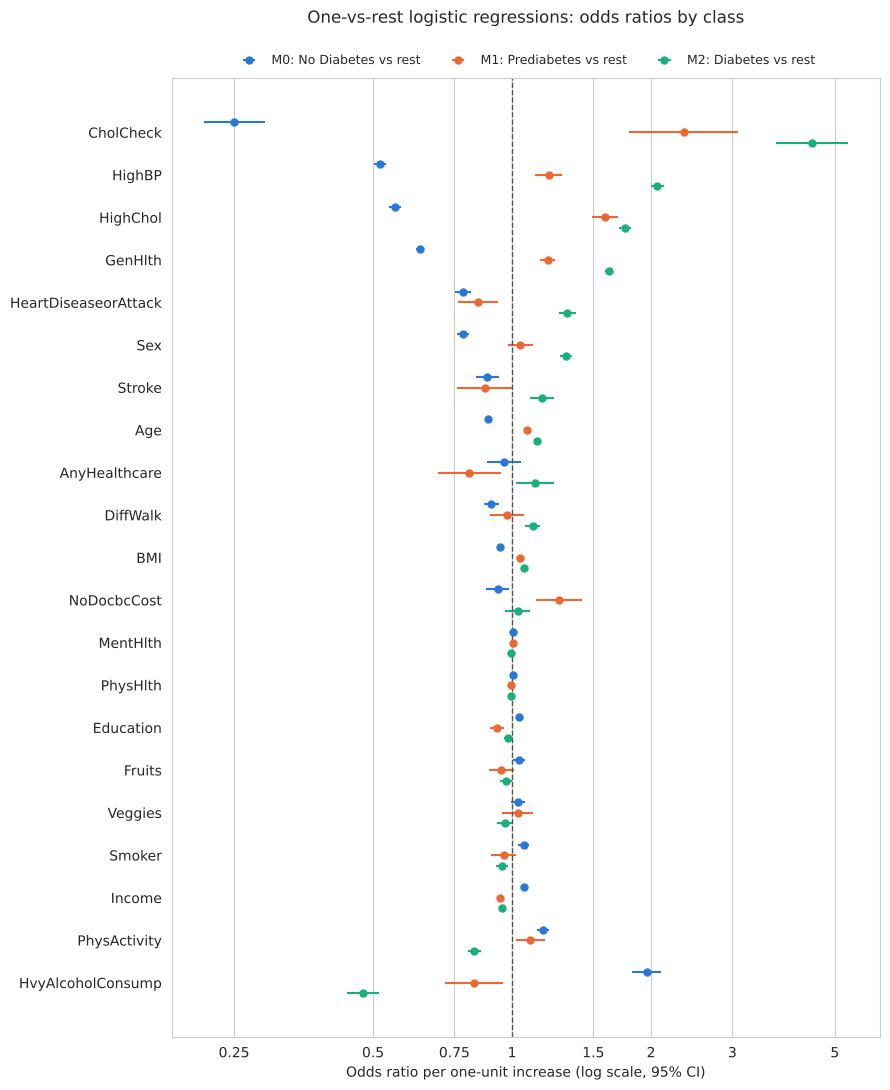

In [9]:
# Forest plot: the three models side by side for every predictor (log scale).
plot_order = or_wide.loc[:, 2].sort_values().index          # sorted by OR in the Diabetes model
ypos = np.arange(len(plot_order))
offsets = {0: 0.25, 1: 0.0, 2: -0.25}

fig, ax = plt.subplots(figsize=(9, 11))
for k in CLASSES:
    sub = or_long[or_long["class"] == k].set_index("feature").loc[plot_order]
    ax.errorbar(sub["OR"], ypos + offsets[k],
                xerr=[sub["OR"] - sub["lower"], sub["upper"] - sub["OR"]],
                fmt="o", ms=5, lw=1.5, capsize=0, color=class_colors[k],
                label=f"M{k}: {target_names[k]} vs rest")
ax.axvline(1, color="#52514e", lw=1, ls="--")
ax.set_xscale("log")
ticks = [0.25, 0.5, 0.75, 1, 1.5, 2, 3, 5]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:g}" for t in ticks])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_yticks(ypos)
ax.set_yticklabels(plot_order)
ax.set_xlabel("Odds ratio per one-unit increase (log scale, 95% CI)")
ax.set_title("One-vs-rest logistic regressions: odds ratios by class")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)
ax.set_title("One-vs-rest logistic regressions: odds ratios by class", pad=40)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [10]:
# Which predictors keep the same direction across the three models, and which flip?
direction = np.sign(or_long.pivot(index="feature", columns="class", values="coef"))
sig = or_long.pivot(index="feature", columns="class", values="p_value") < 0.05
summary_dir = pd.DataFrame({
    f"M{k}": np.where(~sig[k], "n.s.", np.where(direction[k] > 0, "↑ risk", "↓ risk")) for k in CLASSES
}, index=direction.index)
summary_dir.columns = [f"M{k} {target_names[k]}" for k in CLASSES]
summary_dir["M1 and M2 agree"] = summary_dir.iloc[:, 1] == summary_dir.iloc[:, 2]
print("Direction of each association at α = 0.05 ('↑ risk' = raises odds of being in that class):")
summary_dir.loc[order]

Direction of each association at α = 0.05 ('↑ risk' = raises odds of being in that class):


,M0 No Diabetes,M1 Prediabetes,M2 Diabetes,M1 and M2 agree
feature,,,,
BMI,↓ risk,↑ risk,↑ risk,True
GenHlth,↓ risk,↑ risk,↑ risk,True
HighBP,↓ risk,↑ risk,↑ risk,True
Age,↓ risk,↑ risk,↑ risk,True
HighChol,↓ risk,↑ risk,↑ risk,True
HvyAlcoholConsump,↑ risk,↓ risk,↓ risk,True
Sex,↓ risk,n.s.,↑ risk,False
CholCheck,↓ risk,↑ risk,↑ risk,True
Income,↑ risk,↓ risk,↓ risk,True


**How to read the three sets of odds ratios**

- **M0 (No Diabetes vs rest)** is, by construction, close to the mirror image of a "any diabetes" model: its ORs sit on the opposite side of 1 from M2 for almost every predictor. It is useful as a "who is metabolically healthy" profile and should agree with the imbalanced binary model in the R analysis (inverted).
- **M2 (Diabetes vs rest)** reproduces the familiar risk profile — high blood pressure, high cholesterol, BMI, poor general health, age, cholesterol check, and male sex raise the odds; heavy alcohol consumption and higher income lower them.
- **M1 (Prediabetes vs rest)** is the novel model. Its "rest" group contains *both* healthy respondents and diabetics. Risk factors shared with diabetes (e.g. HighBP, GenHlth, HeartDisease) are therefore attenuated or even reversed, because diabetics in the reference group carry them even more strongly. Predictors whose OR stays clearly above 1 in M1 (e.g. HighChol, BMI, CholCheck, NoDocbcCost) are the ones that distinguish prediabetes from **both** neighbouring classes. The sensitivity analysis at the end of the notebook separates these two effects.

## Discrimination on the test set

For each model we report:
- **ROC AUC** — probability that a random member of the class receives a higher score than a random non-member (0.5 = chance).
- **Average precision (PR AUC)** — area under the precision–recall curve. With a 2.4% class, this is the more honest metric: its chance level equals the class prevalence, not 0.5.
- **Brier score** — mean squared error of the predicted probabilities (lower is better), compared with a "no-skill" model that always predicts the class prevalence.

In [11]:
p_test = pd.DataFrame({k: models[k].predict(X_test) for k in CLASSES})
y_test = test[TARGET].values

disc_rows = []
for k in CLASSES:
    yk = (y_test == k).astype(int)
    prev = yk.mean()
    disc_rows.append({
        "model": f"M{k} {target_names[k]}",
        "prevalence": prev,
        "ROC_AUC": roc_auc_score(yk, p_test[k]),
        "PR_AUC": average_precision_score(yk, p_test[k]),
        "PR_AUC_chance": prev,
        "PR_lift_over_chance": average_precision_score(yk, p_test[k]) / prev,
        "Brier": brier_score_loss(yk, p_test[k]),
        "Brier_no_skill": prev * (1 - prev),
    })
disc = pd.DataFrame(disc_rows).set_index("model")
disc["Brier_skill_score"] = 1 - disc["Brier"] / disc["Brier_no_skill"]
disc.round(4)

,prevalence,ROC_AUC,PR_AUC,PR_AUC_chance,PR_lift_over_chance,Brier,Brier_no_skill,Brier_skill_score
model,,,,,,,,
M0 No Diabetes,0.8342,0.8065,0.9518,0.8342,1.1409,0.1133,0.1383,0.1808
M1 Prediabetes,0.0238,0.6854,0.0453,0.0238,1.9046,0.0230,0.0232,0.0088
M2 Diabetes,0.1420,0.8149,0.4106,0.1420,2.8909,0.1008,0.1218,0.1724


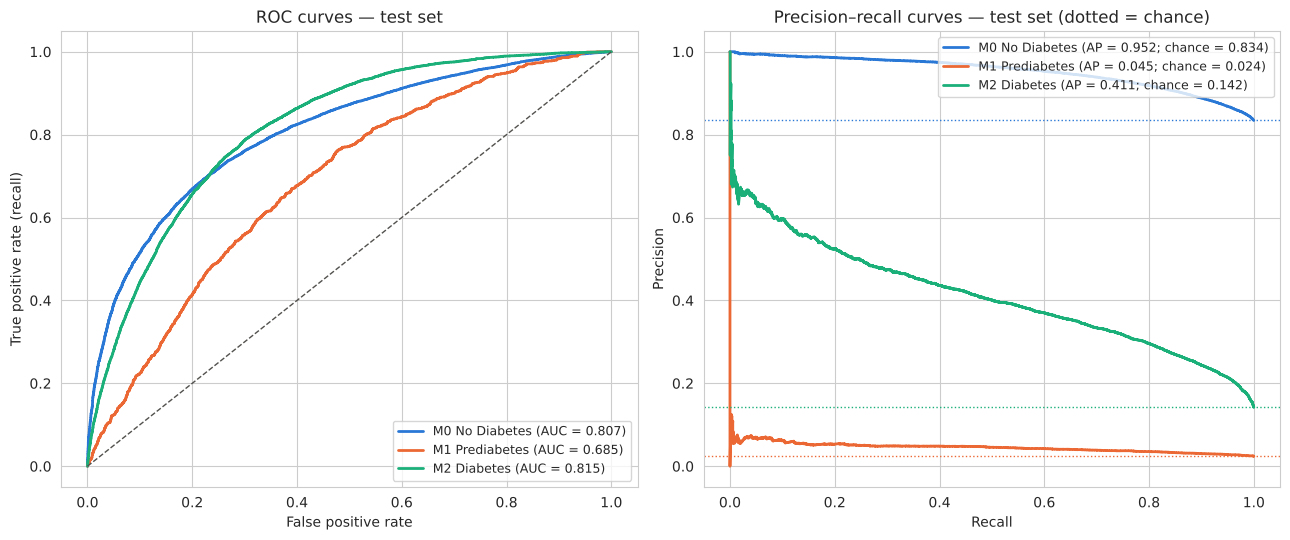

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for k in CLASSES:
    yk = (y_test == k).astype(int)
    fpr, tpr, _ = roc_curve(yk, p_test[k])
    axes[0].plot(fpr, tpr, lw=2, color=class_colors[k],
                 label=f"M{k} {target_names[k]} (AUC = {roc_auc_score(yk, p_test[k]):.3f})")
    prec, rec, _ = precision_recall_curve(yk, p_test[k])
    axes[1].plot(rec, prec, lw=2, color=class_colors[k],
                 label=f"M{k} {target_names[k]} (AP = {average_precision_score(yk, p_test[k]):.3f}; chance = {yk.mean():.3f})")
    axes[1].axhline(yk.mean(), color=class_colors[k], lw=1, ls=":")
axes[0].plot([0, 1], [0, 1], color="#52514e", lw=1, ls="--")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curves — test set")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curves — test set (dotted = chance)")
for ax in axes:
    ax.legend(loc="lower right" if ax is axes[0] else "upper right", fontsize=9)
plt.tight_layout()
plt.show()

### Calibration

Because the models are fitted without re-weighting, their predicted probabilities should line up with observed frequencies. Points on the diagonal mean that, e.g., among respondents given a 20% probability of diabetes, about 20% actually have it. Calibrated probabilities are what make the threshold choice below meaningful. Note the range of the Prediabetes panel: M1 almost never assigns more than ~6% probability to anyone, which is why a 0.5 cut-off flags no one.

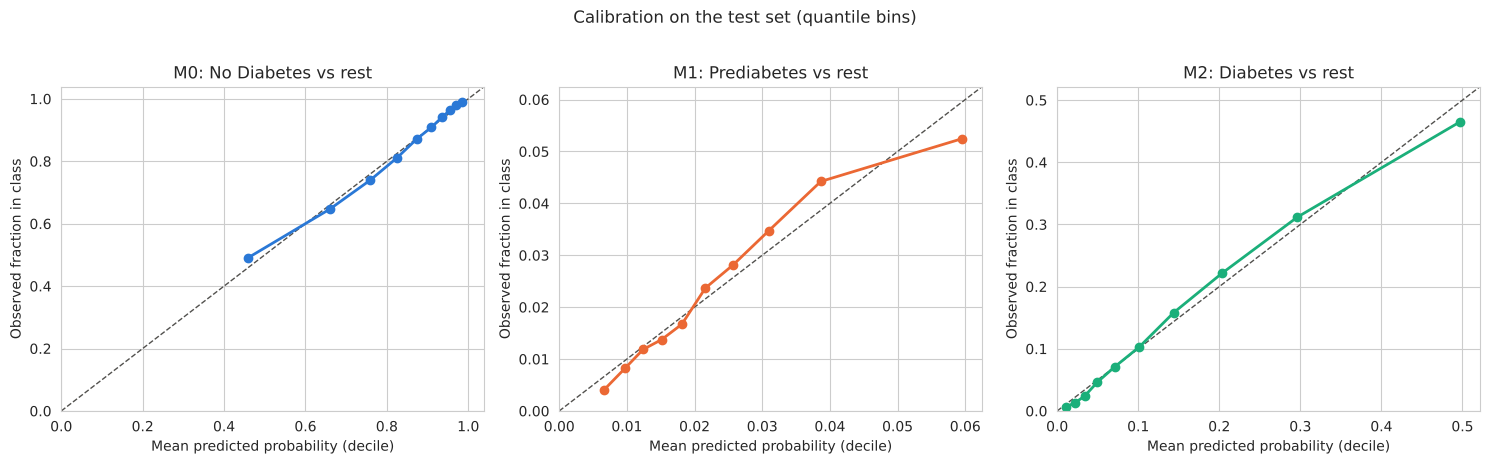

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, k in zip(axes, CLASSES):
    yk = (y_test == k).astype(int)
    frac_pos, mean_pred = calibration_curve(yk, p_test[k], n_bins=10, strategy="quantile")
    lim = max(frac_pos.max(), mean_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="#52514e", lw=1, ls="--")
    ax.plot(mean_pred, frac_pos, "o-", lw=2, ms=6, color=class_colors[k])
    ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="Mean predicted probability (decile)",
           ylabel="Observed fraction in class", title=f"M{k}: {target_names[k]} vs rest")
plt.suptitle("Calibration on the test set (quantile bins)", y=1.02)
plt.tight_layout()
plt.show()

## Choosing a decision threshold for each model

The default 0.5 cut-off is inappropriate for rare classes: a respondent would need a >50% predicted probability of prediabetes to be flagged, which almost never happens. We therefore choose one threshold per model **on the training data only**, using 5-fold stratified cross-validation:

1. Fit each OvR model on 4 folds and predict the held-out fold → out-of-fold (OOF) probabilities for every training row.
2. For each model, pick the threshold that **maximises F1** for its class on the OOF probabilities (balances precision and recall). Youden's J (max sensitivity + specificity − 1) is reported alongside for reference.
3. Apply the chosen thresholds, unchanged, to the test set.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof = pd.DataFrame(0.0, index=train.index, columns=CLASSES)
for tr_idx, va_idx in skf.split(X_train, train[TARGET]):
    for k in CLASSES:
        y_tr = ovr_target(train[TARGET].iloc[tr_idx], k)
        fit = sm.Logit(y_tr, X_train.iloc[tr_idx]).fit(disp=0, maxiter=200)
        oof.loc[va_idx, k] = fit.predict(X_train.iloc[va_idx]).values

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    i = np.nanargmax(f1[:-1])
    return thr[i], f1[i]

def youden_threshold(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    i = np.argmax(tpr - fpr)
    return thr[i]

thresholds, thr_rows = {}, []
for k in CLASSES:
    yk = ovr_target(train[TARGET], k)
    t_f1, f1_val = best_f1_threshold(yk, oof[k])
    thresholds[k] = t_f1
    thr_rows.append({"model": f"M{k} {target_names[k]}", "OOF_ROC_AUC": roc_auc_score(yk, oof[k]),
                     "F1-optimal threshold": t_f1, "OOF F1 at that threshold": f1_val,
                     "Youden threshold": youden_threshold(yk, oof[k])})
pd.DataFrame(thr_rows).set_index("model").round(4)

,OOF_ROC_AUC,F1-optimal threshold,OOF F1 at that threshold,Youden threshold
model,,,,
M0 No Diabetes,0.8063,0.4254,0.9118,0.8446
M1 Prediabetes,0.6831,0.0398,0.0853,0.0209
M2 Diabetes,0.8144,0.2054,0.4558,0.1413


In [15]:
# Test-set performance of each binary model: default 0.5 vs CV-tuned threshold.
def binary_metrics(y, p, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn)
    return {"threshold": t, "accuracy": (tp + tn) / len(y), "precision": precision, "recall": recall,
            "specificity": tn / (tn + fp), "F1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0,
            "n_flagged": int(pred.sum())}

rows = []
for k in CLASSES:
    yk = (y_test == k).astype(int)
    for label, t in [("0.5 (default)", 0.5), ("CV-tuned", thresholds[k])]:
        rows.append({"model": f"M{k} {target_names[k]}", "rule": label, **binary_metrics(yk, p_test[k].values, t)})
bin_perf = pd.DataFrame(rows).set_index(["model", "rule"])
bin_perf.round(3)

threshold  accuracy  precision  recall  specificity     F1  n_flagged
model          rule                                                                                
M0 No Diabetes 0.5 (default)      0.500     0.841      0.858   0.971        0.191  0.911      44628
               CV-tuned           0.425     0.842      0.849   0.985        0.121  0.912      45739
M1 Prediabetes 0.5 (default)      0.500     0.976      0.000   0.000        1.000  0.000          0
               CV-tuned           0.040     0.854      0.049   0.277        0.868  0.083       6402
M2 Diabetes    0.5 (default)      0.500     0.862      0.552   0.158        0.979  0.245       1917
               CV-tuned           0.205     0.790      0.361   0.625        0.817  0.458      11608

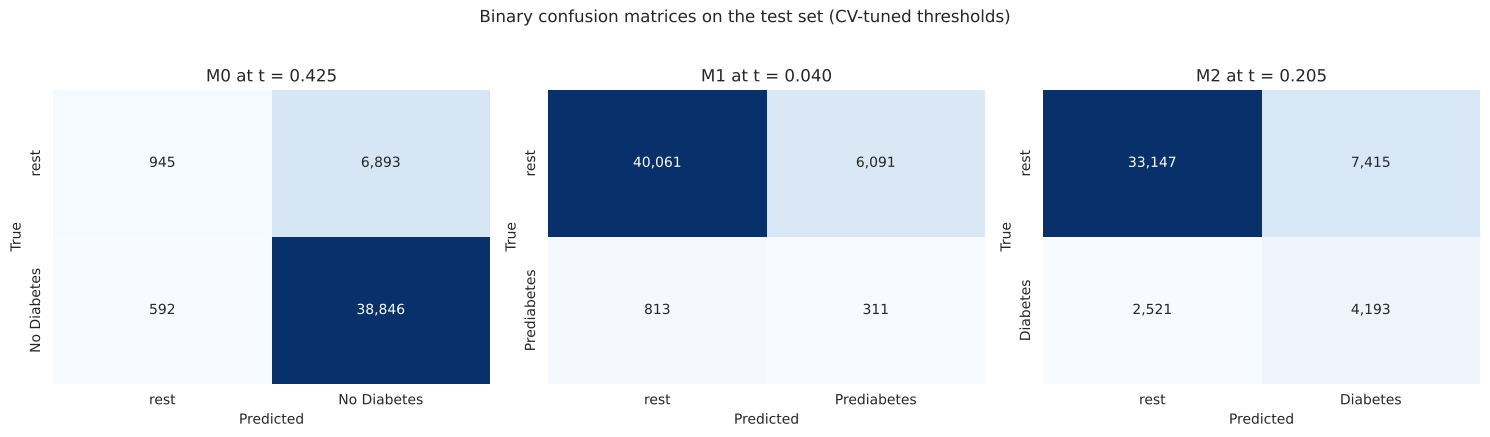

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, k in zip(axes, CLASSES):
    yk = (y_test == k).astype(int)
    cm = confusion_matrix(yk, (p_test[k] >= thresholds[k]).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["rest", target_names[k]], yticklabels=["rest", target_names[k]])
    ax.set(xlabel="Predicted", ylabel="True", title=f"M{k} at t = {thresholds[k]:.3f}")
plt.suptitle("Binary confusion matrices on the test set (CV-tuned thresholds)", y=1.03)
plt.tight_layout()
plt.show()

## Combining the three models into one 3-class prediction

Each respondent now has three probabilities $\hat p_0, \hat p_1, \hat p_2$ from three independent models (they need not sum to 1). We compare three ways of turning them into a single label:

- **Rule A — normalised argmax:** rescale the three probabilities to sum to 1 and pick the largest. This is the standard scikit-learn OvR rule and is the analogue of the multinomial argmax rule from the R analysis.
- **Rule B — threshold-scaled argmax:** divide each probability by its CV-tuned threshold, $\hat p_k / t_k$, and pick the largest ratio. A class wins when its probability is *furthest above its own cut-off*, which puts rare classes on an equal footing with the majority class.
- **Rule C — hierarchical rule:** flag Diabetes if $\hat p_2 \ge t_2$; otherwise flag Prediabetes if $\hat p_1 \ge t_1$; otherwise No Diabetes. This mirrors clinical triage (rule out the more severe condition first).

As benchmarks we fit the **multinomial logistic regression** (same predictors, same split; reproduces the R `multinom` model) and the **majority-class baseline**. Because of the imbalance, **macro-F1** (unweighted mean of the three per-class F1 scores) is the main comparison metric, alongside per-class recall.

In [17]:
P = p_test[CLASSES].values
T = np.array([thresholds[k] for k in CLASSES])

pred_A = np.argmax(P / P.sum(axis=1, keepdims=True), axis=1)
pred_B = np.argmax(P / T, axis=1)
pred_C = np.where(P[:, 2] >= T[2], 2, np.where(P[:, 1] >= T[1], 1, 0))

# Benchmark: multinomial logistic regression (reference class = No Diabetes)
mn = sm.MNLogit(train[TARGET], X_train).fit(disp=0, maxiter=300, method="newton")
P_mn = mn.predict(X_test).values
pred_mn = np.argmax(P_mn, axis=1)
pred_base = np.zeros_like(y_test)

def multiclass_summary(y, pred):
    prec, rec, f1, _ = precision_recall_fscore_support(y, pred, labels=CLASSES, zero_division=0)
    out = {"accuracy": accuracy_score(y, pred), "macro_F1": f1.mean()}
    for k in CLASSES:
        out[f"recall_{k}"] = rec[k]
    for k in CLASSES:
        out[f"precision_{k}"] = prec[k]
    for k in CLASSES:
        out[f"F1_{k}"] = f1[k]
    return out

rules = {
    "Majority baseline (always 0)": pred_base,
    "Multinomial LR (argmax)": pred_mn,
    "OvR Rule A: normalised argmax": pred_A,
    "OvR Rule B: threshold-scaled argmax": pred_B,
    "OvR Rule C: hierarchical thresholds": pred_C,
}
comparison = pd.DataFrame({name: multiclass_summary(y_test, pr) for name, pr in rules.items()}).T
comparison = comparison.rename(columns=lambda c: c.replace("_0", " NoDiab").replace("_1", " PreDiab").replace("_2", " Diab"))
comparison.round(3)

,accuracy,macro_F1,recall NoDiab,recall PreDiab,recall Diab,precision NoDiab,precision PreDiab,precision Diab,F1 NoDiab,F1 PreDiab,F1 Diab
Majority baseline (always 0),0.834,0.303,1.000,0.000,0.000,0.834,0.000,0.000,0.910,0.000,0.000
Multinomial LR (argmax),0.840,0.394,0.976,0.000,0.180,0.855,0.000,0.534,0.911,0.000,0.269
OvR Rule A: normalised argmax,0.840,0.394,0.976,0.000,0.180,0.855,0.000,0.535,0.911,0.000,0.269
OvR Rule B: threshold-scaled argmax,0.821,0.447,0.914,0.012,0.407,0.884,0.080,0.433,0.898,0.022,0.420
OvR Rule C: hierarchical thresholds,0.770,0.451,0.816,0.023,0.625,0.914,0.055,0.361,0.862,0.033,0.458


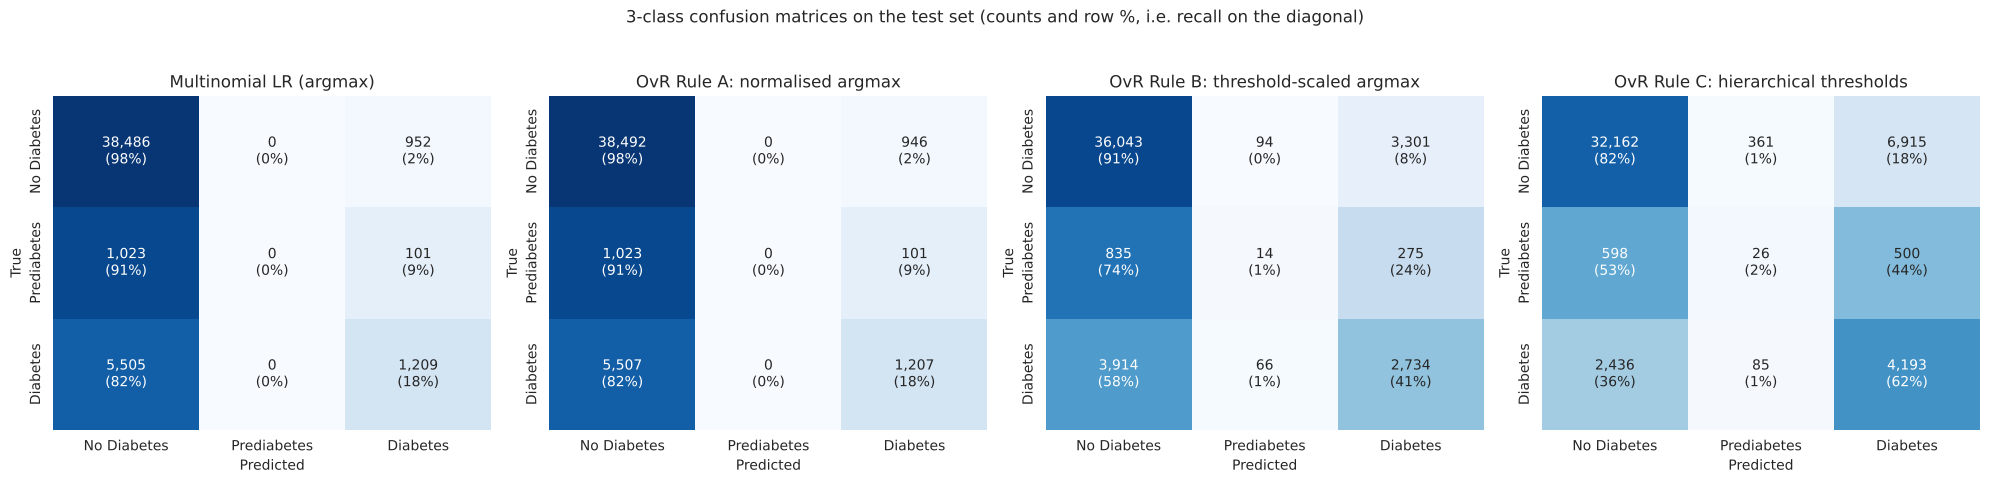

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
labels = [target_names[k] for k in CLASSES]
for ax, name in zip(axes, ["Multinomial LR (argmax)", "OvR Rule A: normalised argmax",
                           "OvR Rule B: threshold-scaled argmax", "OvR Rule C: hierarchical thresholds"]):
    cm = confusion_matrix(y_test, rules[name], labels=CLASSES)
    cm_row = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_row, annot=np.array([[f"{v:,}\n({r:.0%})" for v, r in zip(rv, rr)] for rv, rr in zip(cm, cm_row)]),
                fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax, xticklabels=labels, yticklabels=labels)
    ax.set(xlabel="Predicted", ylabel="True", title=name)
plt.suptitle("3-class confusion matrices on the test set (counts and row %, i.e. recall on the diagonal)", y=1.04)
plt.tight_layout()
plt.show()

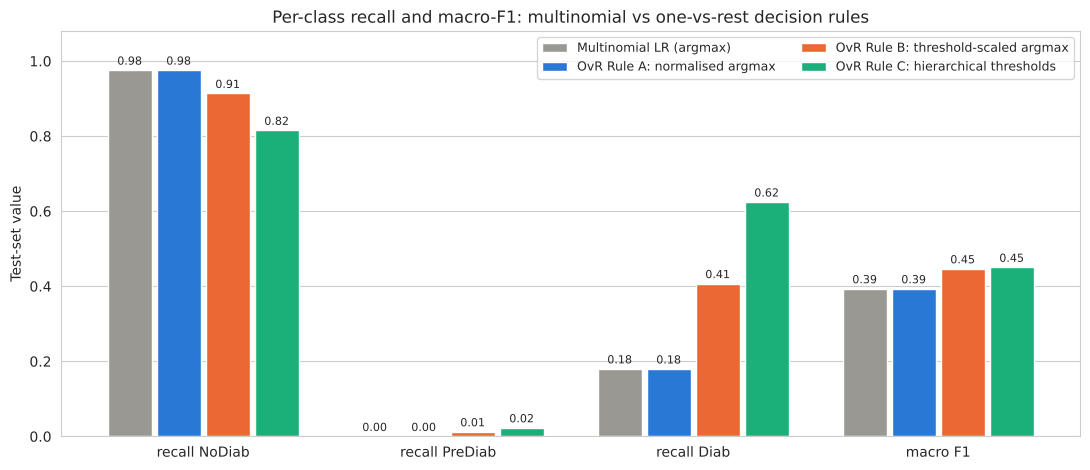

In [19]:
# Visual summary: per-class recall and macro-F1 for each rule.
plot_rules = ["Multinomial LR (argmax)", "OvR Rule A: normalised argmax",
              "OvR Rule B: threshold-scaled argmax", "OvR Rule C: hierarchical thresholds"]
metrics = ["recall NoDiab", "recall PreDiab", "recall Diab", "macro F1"]
comparison_plot = comparison.rename(columns={"macro_F1": "macro F1"})
x = np.arange(len(metrics))
w = 0.2
greys = ["#9a9893", "#2a78d6", "#eb6834", "#1baf7a"]

fig, ax = plt.subplots(figsize=(11, 4.8))
for i, (r, c) in enumerate(zip(plot_rules, greys)):
    vals = comparison_plot.loc[r, metrics].values.astype(float)
    bars = ax.bar(x + (i - 1.5) * w, vals, width=w - 0.02, color=c, label=r)
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in vals], fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Test-set value")
ax.set_title("Per-class recall and macro-F1: multinomial vs one-vs-rest decision rules")
ax.legend(fontsize=9, loc="upper right", ncol=2)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### Ranking ability: OvR models vs the multinomial model

Decision rules aside, do three separate models rank respondents better or worse than one multinomial model? The OvR AUC of the multinomial probabilities (as reported in the R analysis) is compared with the AUC of each dedicated binary model.

In [20]:
auc_cmp = pd.DataFrame({
    "Dedicated OvR model": [roc_auc_score((y_test == k).astype(int), P[:, k]) for k in CLASSES],
    "Multinomial LR": [roc_auc_score((y_test == k).astype(int), P_mn[:, k]) for k in CLASSES],
    "PR_AUC OvR": [average_precision_score((y_test == k).astype(int), P[:, k]) for k in CLASSES],
    "PR_AUC multinomial": [average_precision_score((y_test == k).astype(int), P_mn[:, k]) for k in CLASSES],
}, index=[target_names[k] for k in CLASSES])
auc_cmp.round(4)

,Dedicated OvR model,Multinomial LR,PR_AUC OvR,PR_AUC multinomial
No Diabetes,0.8065,0.8065,0.9518,0.9518
Prediabetes,0.6854,0.6886,0.0453,0.0464
Diabetes,0.8149,0.8150,0.4106,0.4108


## Sensitivity analysis: what drives the Prediabetes model?

In M1 the reference group mixes healthy respondents (≈ 85%) and diabetics (≈ 15%). To see whether a prediabetes odds ratio reflects "riskier than healthy people" or "less risky than diabetics", we refit the prediabetes outcome against **No Diabetes only** (diabetics excluded) and compare the odds ratios with M1. Predictors whose OR grows when diabetics are removed are shared diabetes risk factors that M1 under-states.

In [21]:
mask = train[TARGET].isin([0, 1])
m1_vs0 = sm.Logit((train.loc[mask, TARGET] == 1).astype(int), X_train.loc[mask]).fit(disp=0, maxiter=200)

ci_s = m1_vs0.conf_int()
sens = pd.DataFrame({
    "OR M1 (vs everyone else)": np.exp(models[1].params[feature_cols]),
    "OR Prediabetes vs No Diabetes only": np.exp(m1_vs0.params[feature_cols]),
    "95% CI (vs No Diabetes)": [f"[{np.exp(ci_s.loc[v, 0]):.3f}, {np.exp(ci_s.loc[v, 1]):.3f}]" for v in feature_cols],
    "OR M2 Diabetes (for reference)": np.exp(models[2].params[feature_cols]),
})
sens["change (log-OR)"] = np.log(sens.iloc[:, 1]) - np.log(sens.iloc[:, 0])
sens.sort_values("change (log-OR)", ascending=False).round(3)

,OR M1 (vs everyone else),OR Prediabetes vs No Diabetes only,95% CI (vs No Diabetes),OR M2 Diabetes (for reference),change (log-OR)
HighBP,1.199,1.369,"[1.281, 1.464]",2.063,0.132
HighChol,1.587,1.793,"[1.682, 1.911]",1.753,0.122
CholCheck,2.354,2.642,"[2.013, 3.467]",4.464,0.116
HeartDiseaseorAttack,0.845,0.947,"[0.857, 1.046]",1.318,0.114
GenHlth,1.195,1.304,"[1.255, 1.355]",1.623,0.087
DiffWalk,0.975,1.049,"[0.963, 1.144]",1.109,0.073
Sex,1.042,1.091,"[1.025, 1.162]",1.310,0.046
Stroke,0.873,0.913,"[0.793, 1.051]",1.161,0.044
AnyHealthcare,0.808,0.835,"[0.712, 0.980]",1.120,0.033
BMI,1.039,1.052,"[1.048, 1.056]",1.060,0.012


## Summary

The cell below prints the key numbers so the conclusions can be checked against the outputs above.

In [22]:
print("Test-set discrimination of the three one-vs-rest models:")
for k in CLASSES:
    r = disc.loc[f"M{k} {target_names[k]}"]
    print(f"  M{k} {target_names[k]:<12} ROC AUC = {r.ROC_AUC:.3f} | PR AUC = {r.PR_AUC:.3f} "
          f"(chance {r.prevalence:.3f}, lift x{r.PR_lift_over_chance:.1f}) | CV-tuned threshold = {thresholds[k]:.3f}")
print()
cols = ["accuracy", "macro_F1", "recall PreDiab", "recall Diab"]
print(comparison[cols].round(3).to_string())
best = comparison.drop(index="Majority baseline (always 0)")["macro_F1"].idxmax()
print(f"\nBest macro-F1: {best} ({comparison.loc[best, 'macro_F1']:.3f}) vs multinomial "
      f"({comparison.loc['Multinomial LR (argmax)', 'macro_F1']:.3f})")

Test-set discrimination of the three one-vs-rest models:
  M0 No Diabetes  ROC AUC = 0.807 | PR AUC = 0.952 (chance 0.834, lift x1.1) | CV-tuned threshold = 0.425
  M1 Prediabetes  ROC AUC = 0.685 | PR AUC = 0.045 (chance 0.024, lift x1.9) | CV-tuned threshold = 0.040
  M2 Diabetes     ROC AUC = 0.815 | PR AUC = 0.411 (chance 0.142, lift x2.9) | CV-tuned threshold = 0.205

                                     accuracy  macro_F1  recall PreDiab  recall Diab
Majority baseline (always 0)            0.834     0.303           0.000        0.000
Multinomial LR (argmax)                 0.840     0.394           0.000        0.180
OvR Rule A: normalised argmax           0.840     0.394           0.000        0.180
OvR Rule B: threshold-scaled argmax     0.821     0.447           0.012        0.407
OvR Rule C: hierarchical thresholds     0.770     0.451           0.023        0.625

Best macro-F1: OvR Rule C: hierarchical thresholds (0.451) vs multinomial (0.394)


### Interpretation

**1. Fitting one model per class does not, by itself, fix the imbalance problem.** With the normalised-argmax rule (Rule A), the three OvR models give exactly the multinomial result: accuracy 0.840, macro-F1 0.394, Prediabetes recall 0 and Diabetes recall 0.18. The two approaches also rank respondents almost identically (test ROC AUCs 0.807 / 0.685 / 0.815 for OvR vs 0.807 / 0.689 / 0.815 for multinomial). That is expected, because both are linear in the same 21 predictors.

**2. What the OvR approach adds is a separate decision threshold per class.** The CV-tuned thresholds are far below 0.5: 0.205 for Diabetes and 0.040 for Prediabetes. Used with them, the Diabetes model's recall rises from 0.16 to 0.62 (precision 0.36). The hierarchical rule (Rule C) raises macro-F1 from 0.394 to 0.451 and Diabetes recall from 0.18 to 0.62, at the cost of overall accuracy (0.840 → 0.770). This is the same trade-off seen in the balanced-vs-imbalanced comparison of the R analysis. The choice of rule (and of the F1 criterion itself) should follow the use case: screening favours recall, resource-limited follow-up favours precision.

**3. Prediabetes remains essentially unidentifiable from these indicators.** M1 has a McFadden pseudo-R² of 0.04 (vs ≈ 0.19 for M0 and M2), a test ROC AUC of 0.685, and a PR AUC of 0.045, only about twice its 2.4% chance level. Used on its own as a screen at its tuned threshold, M1 catches 28% of prediabetic respondents, but only about 1 in 20 flagged respondents is actually prediabetic. In the combined 3-class rules, most of those respondents also clear the Diabetes threshold, so Prediabetes recall falls to 1–2%. The survey predictors separate "healthy" from "diabetic" well, but the intermediate state overlaps with both neighbours. This is a limit of the information in the data, not of the modelling strategy.

**4. The odds ratios tell a consistent clinical story.**
- M0 and M2 are near mirror images.
- In M2 the strongest risk markers are CholCheck (OR 4.46), HighBP (2.06), HighChol (1.75), GenHlth (1.62 per level), male sex (1.31), Age (1.13 per category) and BMI (1.06 per point). Heavy alcohol use (0.48) and higher income (0.95 per level) are associated with lower odds.
- In M1, HighChol (1.59), CholCheck (2.35), BMI (1.04) and Age (1.08) remain clear markers of prediabetes. Cost barriers to care (NoDocbcCost, 1.27) matter for prediabetes but not for diabetes (CI includes 1 in M2). Having health coverage (AnyHealthcare, 0.81) is associated with *lower* odds of prediabetes but higher odds of diabetes. One possible reading is that insured people with abnormal glucose are more often diagnosed and labelled diabetic.
- Predictors tied to established disease are attenuated (HighBP 1.20, GenHlth 1.20) or reversed (HeartDiseaseorAttack 0.85) in M1, because diabetics in the reference group carry them even more strongly.
- The sensitivity analysis confirms this. When diabetics are dropped from the comparison group, the ORs for HighBP, HighChol, CholCheck, HeartDiseaseorAttack and GenHlth move furthest toward the Diabetes model. NoDocbcCost, Income and Education barely change, so those are genuine prediabetes-vs-healthy differences.

**Limitations.** Predictive associations only (cross-sectional, self-reported survey); duplicates and BMI outliers retained; predictors enter linearly in their original units; OvR models are fitted independently, so their probabilities do not sum to 1 and must be combined with a decision rule.

**Possible next steps.** Ordinal logistic regression (the classes are naturally ordered 0 < 1 < 2), non-linear terms for BMI/Age (splines), regularised OvR models (L1 for feature selection), class-weighted fits as an alternative to threshold tuning, and tree-based models (Random Forest, boosting) for comparison.